In [1]:
from curve_builder import Curve
from hw_pricer import HullWhitePricer
from calibration import HullWhiteCalibrator

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.stats import norm
from scipy.optimize import brentq

%reload_ext autoreload
%autoreload 2

In [2]:
# Bachelier (normal) vol from price
def black_normal_vol(price, forward, strike, expiry, notional, annuity):
    """
    Computes the normal (Bachelier) implied volatility (in basis points) from a swaption or caplet price.

    Parameters
    ----------
    price : float
        Market price of the swaption or caplet.
    forward : float
        Forward swap rate.
    strike : float
        Swaption strike rate.
    expiry : float
        Time to expiry in years.
    notional : float
        Notional amount of the swaption or caplet.
    annuity : float
        Annuity factor for the swaption or caplet (DF x Year Frac.).

    Returns
    -------
    float
        Implied normal volatility in basis points (bps).
    """
    forward = forward / 100  # convert percentage to rate units
    strike = strike / 100    # convert percentage to rate units

    def bachelier_price(sigma):
        if sigma <= 0:
            return 0.0
        d = (forward - strike) / (sigma * np.sqrt(expiry))
        price_model = annuity * notional * ((forward - strike) * norm.cdf(d) + sigma * np.sqrt(expiry) * norm.pdf(d))
        return price_model

    def objective(sigma):
        return bachelier_price(sigma) - price

    # Reasonable bounds for normal vols (in rate units)
    try:
        sigma_normal = brentq(objective, 1e-6, 5.0)
    except:
        sigma_normal = np.nan
    return sigma_normal * 10000  # convert to bps

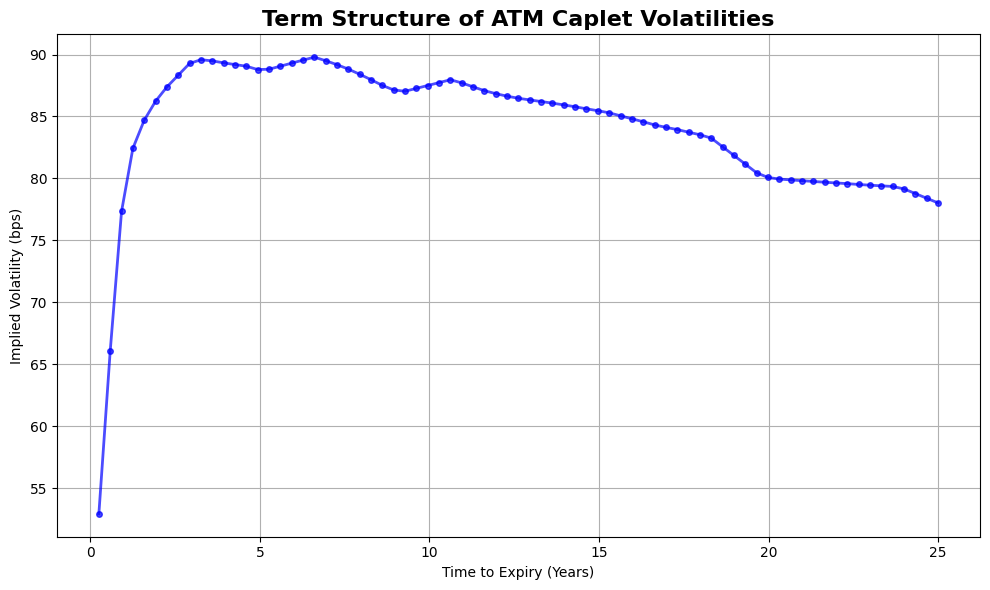

In [3]:
# IR Market data
file = r'CAP_Market_Data_30092025.xlsx'
df_mkt = pd.read_excel(file)
Tenor = 6.00; Moneyness = 0.2

# ATM caplets data
mask1 = df_mkt['Opt_Type'] == 'Caplet'
mask2 = df_mkt['Tenor']  == Tenor
mask3 = df_mkt['Moneyness'].abs() < Moneyness 

# Term structure of vol atm
cplt_atm = df_mkt[mask1 & mask2 & mask3].copy()
cplt_atm.drop_duplicates(subset=['Expiry'], inplace=True)

# Interpolate 
T_vals = np.linspace(0.25, 25, 75)
vol_int_atm = interp1d(cplt_atm['Expiry'].values, cplt_atm['Volatility (Bps)'].values, kind='linear', fill_value="extrapolate")

# Plot
plt.figure(figsize=(10,6))
plt.plot(T_vals, vol_int_atm(T_vals), 'o-', linewidth=2, markersize=4, color='blue', alpha=0.7)
plt.title('Term Structure of ATM Caplet Volatilities', fontsize=16, fontweight='bold')
plt.xlabel('Time to Expiry (Years)')
plt.ylabel('Implied Volatility (bps)')
plt.tight_layout()
plt.grid()
plt.show()


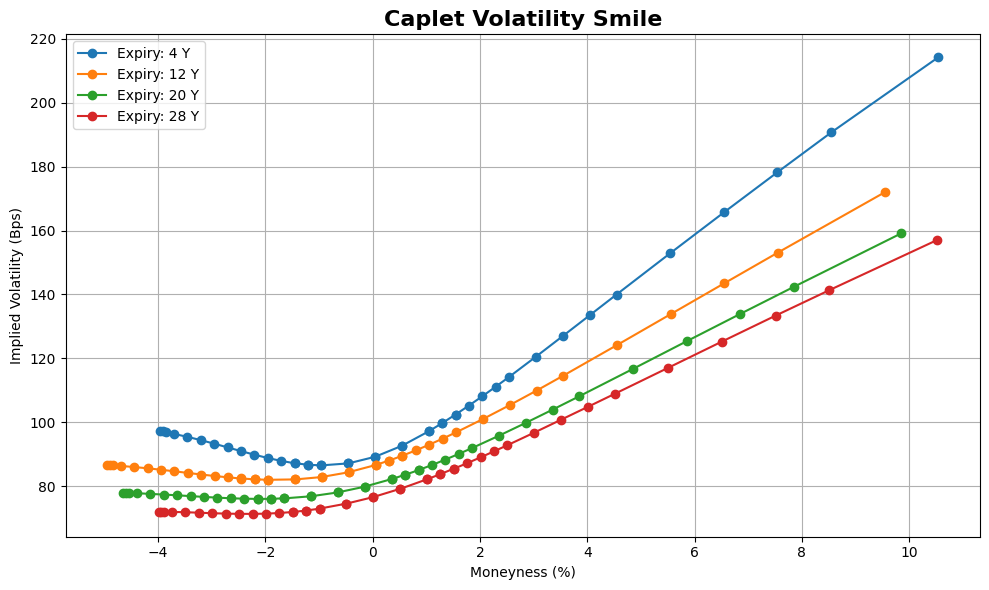

In [4]:
# Smile for various expiries
cplt_smile = df_mkt[['Volatility (Bps)', 'Moneyness', 'Expiry']][df_mkt['Tenor'] == Tenor].sort_values(by='Moneyness').reset_index(drop=True)
expiries = cplt_smile['Expiry'].sort_values().unique()

plt.figure(figsize=(10,6))

for i in range(8, len(expiries), 16):
    mask = cplt_smile['Expiry'] == expiries[i]
    plt.plot(cplt_smile['Moneyness'][mask], cplt_smile['Volatility (Bps)'][mask], 'o-', label=f'Expiry: {round(expiries[i])} Y')

plt.title(f'Caplet Volatility Smile', fontsize=16, fontweight='bold')
plt.xlabel('Moneyness (%)')
plt.ylabel('Implied Volatility (Bps)')
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

In [5]:
# Calibration Template 
file = r'CAP_Calibration_Template_30092025.xlsx'

# Curve 
input_curve = pd.read_excel(file, sheet_name ='Curve')
time = input_curve['Year_Frac']
disc_rate = input_curve['Discount_Factor']
curve = Curve(time, disc_rate)

# Market Prices
df = pd.read_excel(file, sheet_name ='Template')

market_prices = {
    'Prices': df['Price'].tolist(),
    'Strike': df['Strike'].tolist(),
    'Notional': df['Notional'].tolist(),
    'Expiry': df['Expiry'].tolist(),
    'Maturity': df['Maturity'].tolist()}

# Initialize pricer and calibrator, and calibrate to market
pricer = HullWhitePricer(curve)
calibrator = HullWhiteCalibrator(pricer, market_prices)
result = calibrator.calibrate()

a fixed: 0.010000, sigma: 0.000100, RMSRE: 9.60753e-01
a fixed: 0.010000, sigma: 0.008953, RMSRE: 2.34570e-02
a fixed: 0.010000, sigma: 0.009029, RMSRE: 2.32537e-02
a fixed: 0.010000, sigma: 0.008996, RMSRE: 2.29625e-02
a fixed: 0.010000, sigma: 0.008996, RMSRE: 2.29625e-02
a fixed: 0.010000, sigma: 0.008996, RMSRE: 2.29625e-02

Calibration successful:
Iterations: 6
Number of instruments: 48
Total Error:  +2.296%

Parameters:
Fixed a: 0.01000
Optimal sigma: 0.00900

Caplet  0:  1.02Y to 1.52 Y | Model:    20.40 | Market:    19.75 | Diff:  +3.306%
Caplet  1:  1.52Y to 2.02 Y | Model:    23.17 | Market:    23.32 | Diff:  -0.616%
Caplet  2:  2.04Y to 2.54 Y | Model:    27.65 | Market:    27.80 | Diff:  -0.537%
Caplet  3:  3.05Y to 3.55 Y | Model:    23.99 | Market:    24.73 | Diff:  -2.969%
Caplet  4:  3.56Y to 4.06 Y | Model:    27.08 | Market:    27.92 | Diff:  -3.010%
Caplet  5:  4.06Y to 4.56 Y | Model:    29.95 | Market:    30.64 | Diff:  -2.252%
Caplet  6:  4.57Y to 5.07 Y | Model: 

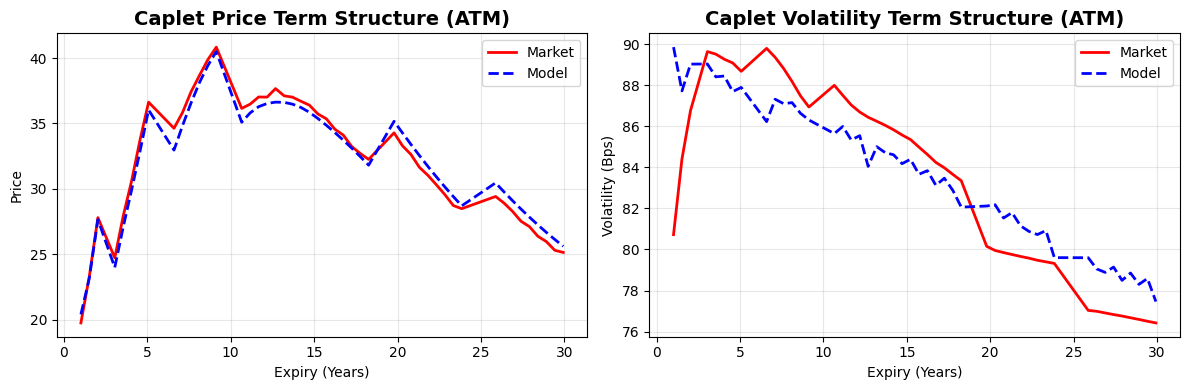

In [6]:
# Plot differences between model and market volatilities
df['Model Price'] = [pricer.caplet(df['Expiry'][i], df['Maturity'][i], df['Notional'][i], df['Strike'][i]/100) for i in range(len(df))]
df['Model Vol'] = [black_normal_vol(df['Model Price'][i], df['Forward'][i], df['Strike'][i], df['Expiry'][i], df['Notional'][i], df['Duration'][i]) for i in range(len(df))]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# price plot 
axes[0].plot(df['Expiry'], df['Price'], 'r-', linewidth=2, label='Market')
axes[0].plot(df['Expiry'], df['Model Price'], 'b--', linewidth=2, label='Model')
axes[0].set_title('Caplet Price Term Structure (ATM)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Expiry (Years)', fontsize=10)
axes[0].set_ylabel('Price', fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=10)

# Volatility Plot
axes[1].plot(df['Expiry'], df['Volatility (Bps)'], 'r-', linewidth=2, label='Market')
axes[1].plot(df['Expiry'], df['Model Vol'], 'b--', linewidth=2, label='Model')
axes[1].set_title('Caplet Volatility Term Structure (ATM)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Expiry (Years)')
axes[1].set_ylabel('Volatility (Bps)')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()


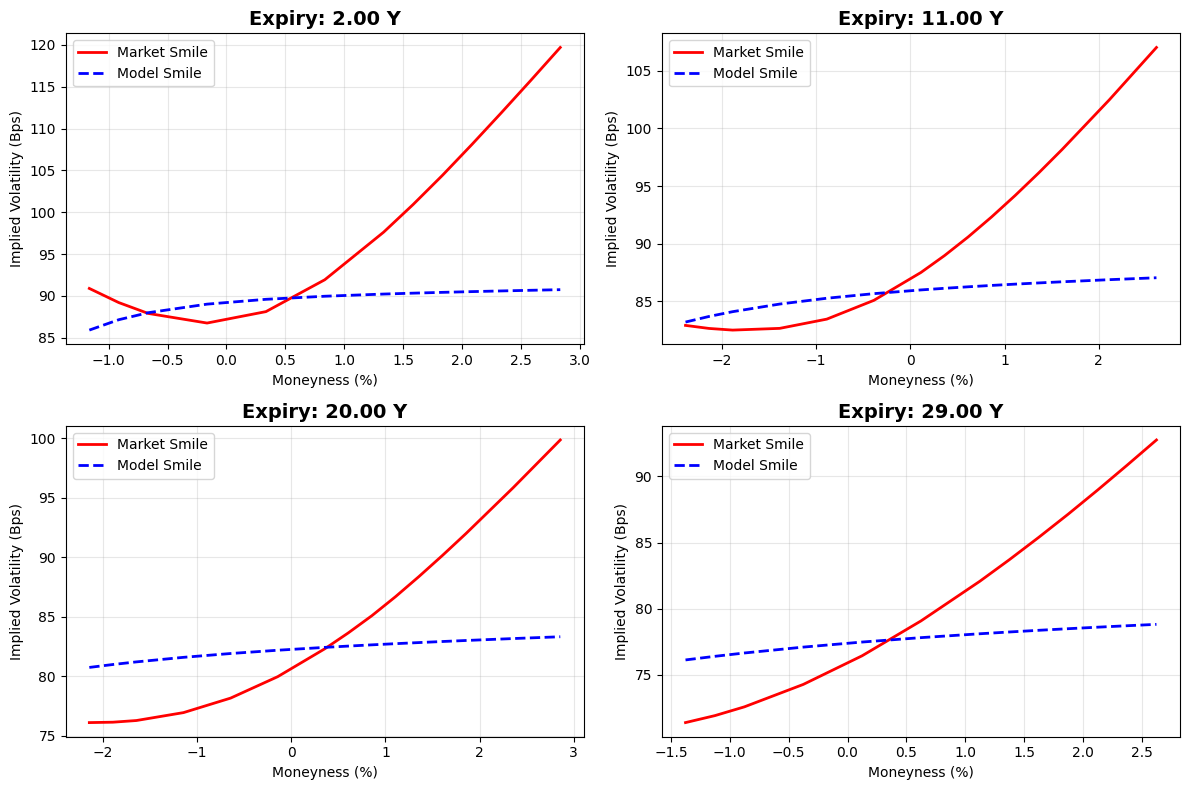

In [7]:
# OTM caplets data
Moneyness = 3.0; Notional = 10_000
mask1 = df_mkt['Opt_Type'] == 'Caplet'
mask2 = df_mkt['Tenor']  == Tenor
mask3 = df_mkt['Moneyness'].abs() < Moneyness 

df = df_mkt[mask1 & mask2 & mask3].copy().reset_index(drop=True)
df['Model Price'] = [pricer.caplet(df['Expiry'][i], df['Maturity'][i], Notional, df['Strike'][i]/100) for i in range(len(df))]
df['Model Vol'] = [black_normal_vol(df['Model Price'][i], df['Forward'][i], df['Strike'][i], df['Expiry'][i], Notional, df['Duration'][i]) for i in range(len(df))] 

df_smile = df[['Volatility (Bps)', 'Moneyness', 'Expiry', 'Model Vol']].sort_values(by='Moneyness').dropna().reset_index(drop=True)
expiries = df_smile['Expiry'].sort_values().unique()

# Subplots for various expiries
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
axs = axs.flatten()

exp_indices = np.linspace(4, len(expiries) - 1, 4, dtype=int)
for ax, idx in zip(axs, exp_indices):
    expiry = expiries[idx]
    mask = df_smile['Expiry'] == expiry
    ax.plot(df_smile['Moneyness'][mask], df_smile['Volatility (Bps)'][mask], 'r-', linewidth = 2, label='Market Smile')
    ax.plot(df_smile['Moneyness'][mask], df_smile['Model Vol'][mask], 'b--', linewidth = 2, label='Model Smile')
    ax.set_title(f'Expiry: {int(expiry):.2f} Y', fontsize=14, fontweight='bold')
    ax.set_xlabel('Moneyness (%)')
    ax.set_ylabel('Implied Volatility (Bps)')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()